# Dead-salmon control — does the structure survive on a RANDOM model?

**Why:** high-dimensional geometry produces plausible-looking structure even in untrained networks (cf. "The Dead Salmons of AI Interpretability", arXiv 2512.18792). Before claiming the trajectory structure reflects *learned computation*, we must check what our exact pipeline outputs on a model with **random, untrained weights**.

**Logic:**
- Structure **vanishes** on the random model → it depends on learned weights → real. 
- Structure **persists** on the random model → it's an architectural/geometric artifact (a dead salmon). 

**Expectation for this project:** M2 (detour magnitude) may persist — a long path through high-dim space is partly just geometry. But M3/M4 (the *content* structure: arithmetic-consistent / facts-erratic / paraphrases-converging) should **collapse** on a random model, because an untrained model has no notion of arithmetic, facts, or meaning. If so, the *interesting* part of the finding is validated while the bare 'it wanders' claim is honestly flagged as weak.

Runs on Colab/Kaggle, GPU + internet. ~5 min (downloads one model; builds the random twin locally, no extra download).

In [1]:
!pip install -q -U transformers
import numpy as np, torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32
MODEL  = "Qwen/Qwen2.5-1.5B-Instruct"   # same model as the main study
print("device:", DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 76.4 MB/s eta 0:00:00:00:01:01
device: cuda


## Prompts (same as main study)

In [2]:
PROMPT_GROUPS = {
    "factual": [
        "The capital of France is", "The chemical symbol for gold is",
        "The first president of the United States was",
        "The author of Romeo and Juliet was William", "The currency used in Japan is the",
    ],
    "arithmetic": [
        "Two plus three equals", "The square root of sixty-four is",
        "Ten minus four equals", "Six times seven equals",
        "One hundred divided by four equals",
    ],
    "commonsense": [
        "The opposite of hot is", "The color of a clear daytime sky is",
        "A triangle has this many sides:", "The freezing point of water in Celsius is",
        "Water is made of hydrogen and",
    ],
}
PROMPTS = [p for g in PROMPT_GROUPS.values() for p in g]

## Load the TRAINED model and build its RANDOM twin
The random twin has the identical architecture (same config, same shapes) but freshly initialized weights — i.e. the same model before any training. Same tokenizer is used for both so inputs are identical.

In [3]:
tok = AutoTokenizer.from_pretrained(MODEL)

print("Loading trained model ...")
trained = AutoModelForCausalLM.from_pretrained(
    MODEL, torch_dtype=DTYPE, output_hidden_states=True).to(DEVICE).eval()

print("Building random-init twin (same architecture, untrained weights) ...")
cfg = AutoConfig.from_pretrained(MODEL)
random_model = AutoModelForCausalLM.from_config(cfg).to(DEVICE).to(DTYPE).eval()
# from_config does NOT load pretrained weights -> weights are freshly initialized.
print("done. Param counts match:",
      sum(p.numel() for p in trained.parameters()) == sum(p.numel() for p in random_model.parameters()))

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Building random-init twin (same architecture, untrained weights) ...
done. Param counts match: True


## Helpers (identical to main study)

In [4]:
@torch.no_grad()
def trajectory(model, prompt, normalize=True):
    inp = tok(prompt, return_tensors="pt").to(DEVICE)
    out = model(**inp, output_hidden_states=True)
    H = torch.stack([h[0, -1, :].float() for h in out.hidden_states])
    if normalize: H = H / (H.norm(dim=-1, keepdim=True) + 1e-8)
    return H.cpu().numpy()

def detour(H):
    steps = np.linalg.norm(np.diff(H, axis=0), axis=1)
    return steps.sum() / (np.linalg.norm(H[-1] - H[0]) + 1e-8)

def step_dirs(H):
    d = np.diff(H, axis=0)
    return d / (np.linalg.norm(d, axis=1, keepdims=True) + 1e-8)

def mean_detour(model):
    return float(np.mean([detour(trajectory(model, p, normalize=True)) for p in PROMPTS]))

def consistency_by_group(model):
    out = {}
    for group, prompts in PROMPT_GROUPS.items():
        dirs = np.stack([step_dirs(trajectory(model, p, normalize=True)) for p in prompts])
        cons = []
        for s in range(dirs.shape[1]):
            V = dirs[:, s, :]; sims = V @ V.T
            cons.append(sims[np.triu_indices(len(V), k=1)].mean())
        out[group] = float(np.mean(cons))
    return out

## M2 control — detour factor: trained vs random

In [5]:
d_trained = mean_detour(trained)
d_random  = mean_detour(random_model)
print(f"angular detour  | trained={d_trained:.2f}  random={d_random:.2f}")
if d_random > 0.7 * d_trained:
    print(">> Detour magnitude PERSISTS on random model → partly geometric artifact.")
    print(">> The bare 'representations wander' claim is weak on its own.")
else:
    print(">> Detour largely DISAPPEARS on random model → depends on learned weights.")

angular detour  | trained=9.07  random=7.11
>> Detour magnitude PERSISTS on random model → partly geometric artifact.
>> The bare 'representations wander' claim is weak on its own.


## M3 control — the key test: does TASK-STRUCTURE survive?
This is the one that matters. A random model has no concept of arithmetic vs facts, so any content-structure (arithmetic consistent, facts erratic) should NOT appear.

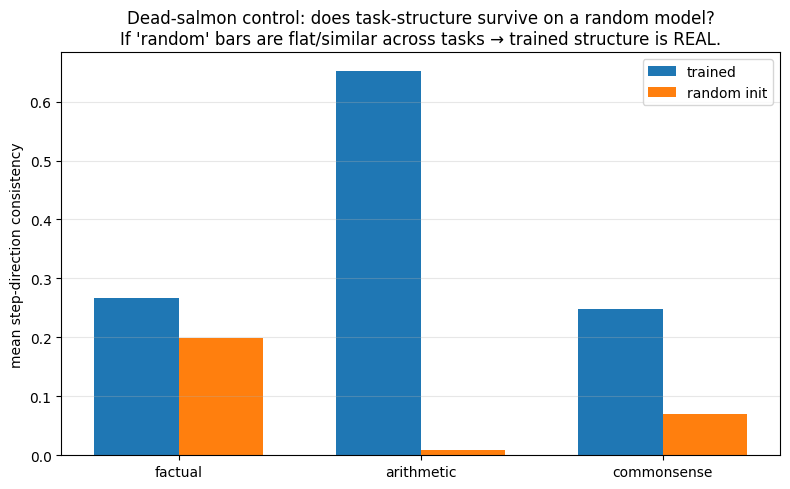

consistency by group:
group            trained    random
factual            0.267     0.198
arithmetic         0.651     0.010
commonsense        0.248     0.071

task spread (max-min) | trained=0.404  random=0.189
>> Trained model SEPARATES tasks far more than random → the task-structured
>> routing is a LEARNED, real effect, not a geometric artifact. NOT a salmon. 


In [8]:
c_trained = consistency_by_group(trained)
c_random  = consistency_by_group(random_model)

groups = list(PROMPT_GROUPS.keys())
x = np.arange(len(groups)); w = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - w/2, [c_trained[g] for g in groups], w, label="trained")
plt.bar(x + w/2, [c_random[g]  for g in groups], w, label="random init")
plt.xticks(x, groups); plt.ylabel("mean step-direction consistency")
plt.title("Dead-salmon control: does task-structure survive on a random model?\n"
          "If 'random' bars are flat/similar across tasks → trained structure is REAL.")
plt.legend(); plt.grid(alpha=0.3, axis="y"); plt.tight_layout()
plt.savefig("plot6_salmon_control.png", dpi=150); plt.show()

print("consistency by group:")
print(f"{'group':<14}{'trained':>10}{'random':>10}")
for g in groups:
    print(f"{g:<14}{c_trained[g]:>10.3f}{c_random[g]:>10.3f}")

# Does the trained model SEPARATE tasks more than the random one?
spread_trained = max(c_trained.values()) - min(c_trained.values())
spread_random  = max(c_random.values())  - min(c_random.values())
print(f"\ntask spread (max-min) | trained={spread_trained:.3f}  random={spread_random:.3f}")
if spread_trained > spread_random + 0.15:
    print(">> Trained model SEPARATES tasks far more than random → the task-structured")
    print(">> routing is a LEARNED, real effect, not a geometric artifact. NOT a salmon. ")
elif spread_random > spread_trained - 0.05:
    print(">> Random model shows similar task spread → the structure may be architectural.")
    print(">> Treat the task-structure claim with caution. ")
else:
    print(">> Intermediate — some learned, some architectural. Report honestly.")

## Interpreting the result

The headline you can honestly claim depends on the M3 control:

- **Trained separates tasks, random doesn't** (expected): the *task-structured routing* finding survives the salmon check — it's learned, not geometric. You can state this as a strength: "all measurements were repeated on a randomly-initialized twin; the task-structure is absent there, ruling out an architectural artifact."
- **Both show similar structure:** the bare detour/wandering is geometric (known weakness), and even the task-structure may be suspect — you'd need to dig further before claiming it's about content.

Either way, running this *before* posting is what turns a salmon-vulnerable geometric claim into a controlled one. Add `plot6_salmon_control.png` and the numbers to the repo, and mention the control up front in any writeup.

In [7]:
import csv
with open("salmon_control_numbers.csv", "w", newline="") as f:
    wr = csv.writer(f)
    wr.writerow(["measurement", "group", "trained", "random"])
    wr.writerow(["M2_detour", "all", round(d_trained,3), round(d_random,3)])
    for g in groups:
        wr.writerow(["M3_consistency", g, round(c_trained[g],3), round(c_random[g],3)])
print("wrote salmon_control_numbers.csv")

wrote salmon_control_numbers.csv
